In [1]:

!pip install torch torchvision matplotlib tqdm


import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [4]:
import os
print(os.listdir('/kaggle/input/datasets'))

['soumikrakshit']


In [5]:
import os
print(os.listdir('/kaggle/input/datasets/soumikrakshit'))

['anime-faces']


In [6]:
import os
print(os.listdir('/kaggle/input/datasets/soumikrakshit/anime-faces'))

['data']


In [7]:
import glob
from PIL import Image

data_path = "/kaggle/input/datasets/soumikrakshit/anime-faces/data"

image_paths = glob.glob(data_path + "/*.png")

print("Total images:", len(image_paths))

Total images: 21551


In [8]:
from torch.utils.data import Dataset

class AnimeDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        
        if self.transform:
            img = self.transform(img)
            
        return img

In [9]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = AnimeDataset(image_paths, transform=transform)

dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Dataset ready ✅")

Dataset ready ✅


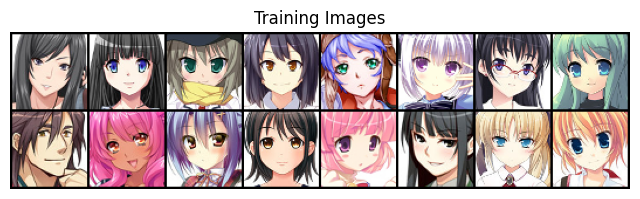

In [10]:
import torchvision
import matplotlib.pyplot as plt

real_batch = next(iter(dataloader))

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")

grid = torchvision.utils.make_grid(real_batch[:16], normalize=True)
plt.imshow(grid.permute(1,2,0))
plt.show()

In [11]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            # Input: (100,1,1)
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # (512,4,4)
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # (256,8,8)
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # (128,16,16)
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # (64,32,32)
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()  # Output: [-1,1]
        )

    def forward(self, x):
        return self.main(x)

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            # (3,64,64)
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # (64,32,32)
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # (128,16,16)
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # (256,8,8)
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # (512,4,4)
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = Generator().to(device)
netD = Discriminator().to(device)

print("Models loaded ✅")

Models loaded ✅


In [14]:
import torch.optim as optim

criterion = nn.BCELoss()

optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [15]:
import torch

num_epochs = 10

G_losses = []
D_losses = []

for epoch in range(num_epochs):
    for i, real_images in enumerate(dataloader):

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)

        # =========================
        # Train Discriminator
        # =========================
        netD.zero_grad()

        # Real images
        outputs = netD(real_images)
        loss_real = criterion(outputs, real_labels)

        # Fake images
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        fake_images = netG(noise)

        outputs = netD(fake_images.detach())
        loss_fake = criterion(outputs, fake_labels)

        lossD = loss_real + loss_fake
        lossD.backward()
        optimizerD.step()

        # =========================
        # Train Generator
        # =========================
        netG.zero_grad()

        outputs = netD(fake_images)
        lossG = criterion(outputs, real_labels)

        lossG.backward()
        optimizerG.step()

    G_losses.append(lossG.item())
    D_losses.append(lossD.item())

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss D: {lossD.item():.4f} | Loss G: {lossG.item():.4f}")

Epoch [1/10] | Loss D: 0.6942 | Loss G: 5.8481
Epoch [2/10] | Loss D: 0.3744 | Loss G: 3.8911
Epoch [3/10] | Loss D: 0.7313 | Loss G: 9.0562
Epoch [4/10] | Loss D: 0.2522 | Loss G: 5.6575
Epoch [5/10] | Loss D: 0.5062 | Loss G: 5.5787
Epoch [6/10] | Loss D: 0.3257 | Loss G: 3.4200
Epoch [7/10] | Loss D: 0.5876 | Loss G: 9.1307
Epoch [8/10] | Loss D: 0.3363 | Loss G: 7.4101
Epoch [9/10] | Loss D: 0.0714 | Loss G: 5.5156
Epoch [10/10] | Loss D: 1.0279 | Loss G: 12.5867


In [16]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 19395
Val size: 2156


In [17]:
import torch.nn as nn

class Critic(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0)
        )

    def forward(self, x):
        return self.main(x).view(-1)

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

netG = Generator().to(device)
netC = Critic().to(device)

In [19]:
import torch.optim as optim

optimizerC = optim.Adam(netC.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [20]:
import torch

def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)

    epsilon = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = epsilon * real + (1 - epsilon) * fake
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    gradients = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(batch_size, -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gp

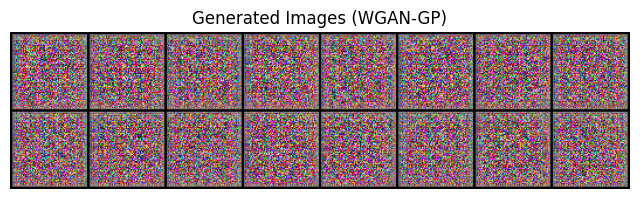

In [21]:
with torch.no_grad():
    noise = torch.randn(16, 100, 1, 1, device=device)
    fake_images = netG(noise).cpu()

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Images (WGAN-GP)")

grid = torchvision.utils.make_grid(fake_images, normalize=True)
plt.imshow(grid.permute(1,2,0))
plt.show()

In [22]:
def evaluate_wgan(netG, netC, val_loader, device):
    netG.eval()
    netC.eval()

    total_g_loss = 0
    total_c_loss = 0

    with torch.no_grad():
        for real_images in val_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            noise = torch.randn(batch_size, 100, 1, 1, device=device)
            fake_images = netG(noise)

            critic_real = netC(real_images)
            critic_fake = netC(fake_images)

            lossC = -(torch.mean(critic_real) - torch.mean(critic_fake))
            lossG = -torch.mean(netC(fake_images))

            total_c_loss += lossC.item()
            total_g_loss += lossG.item()

    netG.train()
    netC.train()

    return total_g_loss / len(val_loader), total_c_loss / len(val_loader)

In [23]:
num_epochs = 10
lambda_gp = 10
critic_iters = 5

G_losses = []
C_losses = []

val_G_losses = []
val_C_losses = []

for epoch in range(num_epochs):
    for i, real_images in enumerate(train_loader):

        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # =========================
        # Train Critic (5 times)
        # =========================
        for _ in range(critic_iters):
            noise = torch.randn(batch_size, 100, 1, 1, device=device)
            fake_images = netG(noise)

            critic_real = netC(real_images)
            critic_fake = netC(fake_images.detach())

            gp = gradient_penalty(netC, real_images, fake_images, device)

            lossC = -(torch.mean(critic_real) - torch.mean(critic_fake)) + lambda_gp * gp

            netC.zero_grad()
            lossC.backward()
            optimizerC.step()

        # =========================
        # Train Generator
        # =========================
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        fake_images = netG(noise)
        lossG = -torch.mean(netC(fake_images))

        netG.zero_grad()
        lossG.backward()
        optimizerG.step()

    # Save training losses
    G_losses.append(lossG.item())
    C_losses.append(lossC.item())

    # =========================
    # VALIDATION
    # =========================
    val_g, val_c = evaluate_wgan(netG, netC, val_loader, device)

    val_G_losses.append(val_g)
    val_C_losses.append(val_c)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train | Loss C: {lossC.item():.4f} | Loss G: {lossG.item():.4f}")
    print(f"Val   | Loss C: {val_c:.4f} | Loss G: {val_g:.4f}")

Epoch [1/10]
Train | Loss C: -31.4481 | Loss G: 37.6702
Val   | Loss C: -11.3474 | Loss G: 30.1589
Epoch [2/10]
Train | Loss C: -19.2201 | Loss G: 22.6325
Val   | Loss C: -5.1793 | Loss G: 19.6518
Epoch [3/10]
Train | Loss C: -20.3356 | Loss G: 19.7847
Val   | Loss C: -10.2216 | Loss G: 15.7747
Epoch [4/10]
Train | Loss C: -41.5855 | Loss G: 25.2181
Val   | Loss C: -3.6110 | Loss G: 24.1336
Epoch [5/10]
Train | Loss C: -25.5745 | Loss G: 33.1202
Val   | Loss C: -7.8423 | Loss G: 27.8195
Epoch [6/10]
Train | Loss C: -26.4669 | Loss G: 41.2449
Val   | Loss C: -2.5984 | Loss G: 37.5255
Epoch [7/10]
Train | Loss C: -5.1598 | Loss G: 37.9209
Val   | Loss C: -0.3841 | Loss G: 36.9395
Epoch [8/10]
Train | Loss C: -33.5135 | Loss G: 43.3318
Val   | Loss C: -6.4832 | Loss G: 38.8298
Epoch [9/10]
Train | Loss C: -25.5362 | Loss G: 44.8278
Val   | Loss C: -1.8122 | Loss G: 38.1317
Epoch [10/10]
Train | Loss C: -37.2782 | Loss G: 28.1699
Val   | Loss C: -4.7313 | Loss G: 33.9410


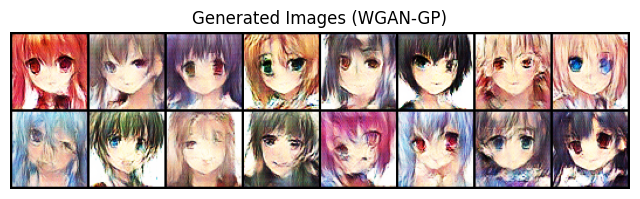

In [24]:
import torchvision
import matplotlib.pyplot as plt

with torch.no_grad():
    noise = torch.randn(16, 100, 1, 1, device=device)
    fake_images = netG(noise).cpu()

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Images (WGAN-GP)")

grid = torchvision.utils.make_grid(fake_images, normalize=True)
plt.imshow(grid.permute(1,2,0))
plt.show()

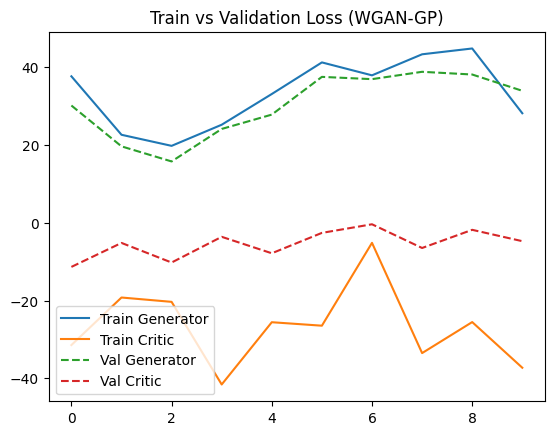

In [25]:
plt.plot(G_losses, label="Train Generator")
plt.plot(C_losses, label="Train Critic")

plt.plot(val_G_losses, '--', label="Val Generator")
plt.plot(val_C_losses, '--', label="Val Critic")

plt.legend()
plt.title("Train vs Validation Loss (WGAN-GP)")
plt.show()

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

def generate_anime_faces(num_images=1, seed=None):
    """Generate anime faces using the trained WGAN-GP generator"""
    if seed is not None and seed > 0:
        torch.manual_seed(int(seed))
    
    # Generate random noise
    noise = torch.randn(num_images, 100, 1, 1, device=device)
    
    # Generate fake images
    with torch.no_grad():
        fake_images = netG(noise).cpu()
    
    # Denormalize from [-1, 1] to [0, 1]
    fake_images = fake_images * 0.5 + 0.5
    fake_images = torch.clamp(fake_images, 0, 1)
    
    # Return single image if only one requested, else return grid
    if num_images == 1:
        img_pil = transforms.ToPILImage()(fake_images[0])
        return img_pil
    else:
        # Create a grid of images
        grid_img = torchvision.utils.make_grid(fake_images, normalize=False)
        grid_img = grid_img.permute(1, 2, 0).numpy()
        return Image.fromarray((grid_img * 255).astype(np.uint8))

In [ ]:
# Create Gradio interface
with gr.Blocks(title="Anime Face Generator (WGAN-GP)") as demo:
    gr.Markdown("# 🎨 Anime Face Generator")
    gr.Markdown("Generate unique anime faces using a trained WGAN-GP model")
    
    with gr.Row():
        with gr.Column():
            num_images = gr.Slider(
                minimum=1,
                maximum=16,
                value=1,
                step=1,
                label="Number of Faces to Generate"
            )
            
            seed_input = gr.Number(
                label="Random Seed (optional)",
                value=None,
                precision=0
            )
            
            generate_btn = gr.Button("🎲 Generate Faces", variant="primary")
        
        with gr.Column():
            output_image = gr.Image(label="Generated Anime Faces")
    
    # Connect button to generation function
    generate_btn.click(
        fn=generate_anime_faces,
        inputs=[num_images, seed_input],
        outputs=output_image
    )

demo.launch()